# Debug notebook for `collect_iterres.py`

This notebook lets you call the script's functions interactively without running it as a CLI script.

**Why a mock `args` is needed:**  
Several functions (`main`, `plot_graphs`) read the module-level `args` variable that is normally
populated by `argparse`. In a notebook `parse_arguments()` would try to parse Jupyter's own
kernel arguments and crash. The cell below injects a fake one instead.

In [1]:
import sys, argparse, os
from paths import scripts_path, data_prod_path, path_to_nn_runs, raw_data_path
import numpy as np
import pandas as pd

# ── Point at the directory that contains collect_iterres.py,
#    paths.py, and analysis.py. Adjust as needed. ──────────────────────────
SCRIPT_DIR = scripts_path
if SCRIPT_DIR not in sys.path:
    sys.path.insert(0, SCRIPT_DIR)

# ── Build a mock args namespace that mirrors every argparse argument.
#    Tweak the values here to control behaviour, exactly as you would
#    pass flags on the command line. ──────────────────────────────────────
mock_args = argparse.Namespace(
    base_dir        = None,          # will use path_to_nn_runs from paths.py
    out_dir         = "/tmp/debug_out/",
    hk_lookup_path  = None,
    weight_pfi      = False,  # True  → sort by WPFI (PFI × test_accuracy)
                              # False → sort by PFI (or UPS if PFI absent)
    top_kmers       = 1000,
    filter_harsh    = False,
    show_cm_bar_percentage = False,
    x_col           = None,
    hue_col         = None,
    group_x_col     = None,
    group_hue_col   = None,
    highlight_multi = False,
    network_top_kmers = 15,
    hostrange_excel = None,
    hostrange_sheet = None
)

#nn_run_dir_name = "IterExcl_encoded_sketches_data2_n500_k12"
nn_run_dir_name = "FFNN_D2"
#nn_run_dir_name = "FFNN_D1_on_D2"
nn_dir = path_to_nn_runs + nn_run_dir_name + "/"
print("NN directory exists:", os.path.isdir(nn_dir))
if not os.path.isdir(nn_dir):
    raise FileNotFoundError(f"NN directory not found: {nn_dir}")
partition_folder = nn_dir + "cluster_b0_p0_run1/"
print("Partition folder exists:", os.path.isdir(partition_folder))

# ── Import the module and immediately overwrite its global `args`.
#    This must happen before calling any function that references `args`. ──
import collect_iterres as cr
cr.args = mock_args

print("Module loaded. cr.args is now:", cr.args)

NN directory exists: True
Partition folder exists: False


/net/domus/home/people/s215045/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Module loaded. cr.args is now: Namespace(base_dir=None, out_dir='/tmp/debug_out/', hk_lookup_path=None, weight_pfi=False, top_kmers=1000, filter_harsh=False, show_cm_bar_percentage=False, x_col=None, hue_col=None, group_x_col=None, group_hue_col=None, highlight_multi=False, network_top_kmers=15, hostrange_excel=None, hostrange_sheet=None)


## Standalone utilities — no `args` dependency

In [ ]:
# ── correct_deci_number ───────────────────────────────────────────────────
# Converts values like 568 → 0.568
print(cr.correct_deci_number(568))   # expect 0.568
print(cr.correct_deci_number(0.75))  # expect 0.75

In [ ]:
# ── calculate_unified_score ───────────────────────────────────────────────
sample_metrics = {
    'test_balanced_accuracy': 0.82,
    'f1': 0.79,
    'unseen_test_balanced_accuracy': 0.71,
}
print("UPS:", cr.calculate_unified_score(sample_metrics))  # expect ~0.763

In [ ]:
from collections import Counter

file_path = os.path.join(data_prod_path, "TEST", nn_run_dir_name, "phage_kmers.txt")

with open(file_path, "r") as f:
    kmer_counts = Counter(line.strip() for line in f if line.strip())

print(kmer_counts)

In [ ]:
from paths import data_prod_path
from pathlib import Path
from Bio import SeqIO
from manipulations import clean_bact_names

root_dir = data_prod_path
strain_name = "Poppous"
kmer = "GTCCTCGGTAGT"

kmer = str(kmer).strip().upper()
pharokka_root = Path(root_dir) / "pharokka"
phold_root = Path(root_dir) / "phold"

pharokka_dirs = [p for p in pharokka_root.rglob("*") if p.is_dir() and strain_name in p.name]
phold_dirs = [p for p in phold_root.rglob("*") if p.is_dir() and strain_name in p.name]
if not pharokka_dirs or len(pharokka_dirs) == 0:
    raise FileNotFoundError(f"No pharokka directory found for strain '{strain_name}' under {pharokka_root}")
if not phold_dirs or len(phold_dirs) == 0:
    raise FileNotFoundError(f"No phold directory found for strain '{strain_name}' under {phold_root}")

pharokka_dir = pharokka_dirs[0]
phold_dir = phold_dirs[0]

ffn_files = sorted(pharokka_dir.glob("**/phanotate.ffn"))
if not ffn_files:
    raise FileNotFoundError(f"No phanotate.ffn file found in {pharokka_dir}")

tsv_files = sorted(phold_dir.glob("**/*_per_cds_predictions.tsv"))
if not tsv_files:
    raise FileNotFoundError(f"No *_per_cds_predictions.tsv file found in {phold_dir}")

matching_cds_ids = []
for record in SeqIO.parse(str(ffn_files[0]), "fasta"):
    print(f"Checking record {record.id} with sequence {record.seq[:30]}...")  # debug print
    print(f"Does the sequence contain the kmer {kmer}? {'Yes' if kmer in str(record.seq).upper() else 'No'}")  # debug print
    if kmer in str(record.seq).upper():
        matching_cds_ids.append(record.id)

cols = [
    "entity", "contig_id", "cds_id", "kmer_in_seq", "start", "end", "phrog", "function", "product",
    "annotation_method", "annotation_confidence", "tophit_protein",
    "function_with_highest_bitscore_proportion", "prostt5_confidence"
]

if not matching_cds_ids:
    print(f"No matching CDS IDs found for kmer '{kmer}' in strain '{strain_name}'.\npharokka_dirs: {pharokka_dirs}\nphold_dirs: {phold_dirs}\nffn_files: {ffn_files}\ntsv_files: {tsv_files}")

ann_df = pd.read_csv(tsv_files[0], sep="\t")
ann_df["kmer_in_seq"] = kmer
ann_df["entity"] = strain_name
missing = [c for c in cols if c not in ann_df.columns]
if missing:
    print(f"Missing normalized interaction rate columns in {tsv_files[0]}: {missing}")

result = ann_df[ann_df["cds_id"].astype(str).isin(matching_cds_ids)][cols].copy()
display(result)

In [ ]:
from Bio import SeqIO

kmer = "GCCAACTATAAG"
#kmer = "ATTCACCAGGTA"
kmer_rc = str(kmer).strip().upper()
kmer_len = len(kmer)
strain_name = "Etui"
OUT_COLS = [
            "entity", "contig_id", "cds_id", "kmer_in_seq", "start", "end",
            "phrog", "function", "product",
            "annotation_method"
        ]
#gbk_files = ["/home/projects/s215045/PredictPhagePPI/data_prod/phold/Etui_Host_1_phold_output/Etui_Host_1.gbk"]
#genome_record = next(SeqIO.parse(str(gbk_files[0]), "genbank"))

fasta_genome = ["/home/projects/s215045/PredictPhagePPI/raw_data/phagehost_KU/data2_phages/Etui_Host_1.fasta"]
genome_record = next(SeqIO.parse(str(fasta_genome[0]), "fasta"))

genome_seq = str(genome_record.seq).upper()

#print(genome_seq)

# ── 2. Find all kmer hit positions (0-based) on both strands ──
kmer_positions = set()
for i in range(len(genome_seq) - kmer_len + 1):
    sub = genome_seq[i: i + kmer_len]
    if sub == kmer or sub == kmer_rc:
        kmer_positions.add(i)

if not kmer_positions:
    print(f"Kmer '{kmer}' (or its RC) not found in genome of '{strain_name}'.")

# ── 3. Find CDS features whose coordinates overlap any kmer position ──
matching_cds_ids = []
for feature in genome_record.features:
    if feature.type != "CDS":
        continue
    # BioPython converts GBK 1-based coords to 0-based half-open [start, end)
    cds_start = int(feature.location.start)
    cds_end   = int(feature.location.end)
    cds_id = (
        feature.qualifiers.get("locus_tag") or
        feature.qualifiers.get("ID") or
        [None]
    )[0]
    if cds_id is None:
        continue
    for pos in kmer_positions:
        if cds_start <= pos and (pos + kmer_len) <= cds_end:
            matching_cds_ids.append(cds_id)
            break  # one hit per CDS is sufficient

## Parse a single log file

In [ ]:
# ── extract_metrics_from_log ──────────────────────────────────────────────
LOG_PATH = "/path/to/your/log_run_something.txt"  # <-- change this

result = cr.extract_metrics_from_log(LOG_PATH)
if result:
    metrics, run_info = result
    print("Metrics:", metrics)
    print("Run info:", run_info)
else:
    print("Parsing failed — check the log format.")

## MetricPlottingUtils — plot from a hand-built DataFrame

Useful for testing the plotting code against a small synthetic dataset
without having to scan an entire run directory.

In [ ]:
OUT = "/tmp/debug_out/"
os.makedirs(OUT, exist_ok=True)

# Minimal synthetic run table — add / remove columns to test edge cases
df_test = pd.DataFrame({
    'folder':                    ['run_a', 'run_b', 'run_c'],
    'n':                         [500,     500,     1000   ],
    'k':                         [12,      20,      12     ],
    'test_accuracy':             [0.81,    0.76,    0.84   ],
    'test_balanced_accuracy':    [0.79,    0.73,    0.82   ],
    'unseen_test_accuracy':      [0.70,    0.65,    0.74   ],
    'unseen_test_balanced_accuracy': [0.68, 0.63,   0.72  ],
    'precision':                 [0.80,    0.74,    0.83   ],
    'recall':                    [0.78,    0.72,    0.81   ],
    'f1':                        [0.79,    0.73,    0.82   ],
    'TN':                        [90,      85,      95     ],
    'FN':                        [10,      15,       8     ],
    'FP':                        [ 8,      12,       6     ],
    'TP':                        [92,      88,      97     ],
    'train_pairs':               [1000,    1000,    1200   ],
    'test_pairs':                [200,     200,     240    ],
    'test_train_ratio':          [0.2,     0.2,     0.2    ],
    'status':                    [True,    True,    True   ],
})

plotter = cr.MetricPlottingUtils(df=df_test, outdir=OUT)

# Individual plot helpers (no args dependency)
plotter._plot_bars(
    x_col='n', y_col='test_balanced_accuracy', hue_col='k',
    title='Balanced accuracy by n/k (test)',
    ylabel='Balanced Accuracy',
    outpath=OUT + 'test_balanced_acc.png'
)
print("Plot saved to", OUT + 'test_balanced_acc.png')

In [ ]:
# ── Call plot_graphs() — requires args.show_cm_bar_percentage ─────────────
# mock_args already sets it to False, so this is safe to run as-is.
plotter.plot_graphs()

## GAPlottingUtils — test annotation plots

`GAPlottingUtils` now takes `sort_by` at construction time (`'PFI'`, `'WPFI'`, or `'UPS'`).
This controls both the kmer ordering in the network plot and the y-axis in
`plot_kmer_against_ups_or_pfi`.

In [ ]:
# Build a tiny synthetic annotation dataframe (mirrors what GA.batch_bact_annotate returns)
annot_df = pd.DataFrame({
    'decoded_kmer': ['ATGCGT', 'CCGATG', 'TTACGG', 'ATGCGT', 'GGCAAT'],
    'bact':         ['E.coli', 'E.coli', 'Salmonella', 'Salmonella', 'E.coli'],
    'gene':         ['geneA', 'geneB', 'geneA', 'geneC', 'geneB'],
    'kmer_in_seq':  [5, 3, 7, 2, 4],
    'PFI':          [0.81, 0.74, 0.68, 0.90, 0.55],
    'UPS':          [0.78, 0.70, 0.65, 0.88, 0.52],
})

# sort_by='PFI' matches the default in the updated script
ga_plotter = cr.GAPlottingUtils(df=annot_df, outdir=OUT, sort_by='PFI')

ga_plotter.plot_top_genes(annot_df, entity_type='bacterium', title_suffix='(test)')
ga_plotter.plot_kmer_distribution(annot_df, entity_type='bacterium', title_suffix='(test)')
# plot_kmer_against_ups_or_pfi no longer takes sort_by — it uses self.sort_by
ga_plotter.plot_kmer_against_ups_or_pfi(annot_df, entity_type='bacterium')
print("Gene plots saved.")

## Run main() end-to-end

Reads from a real run directory. Adjust `base_dir` and `out_dir` below.

Scanning directory: /net/kvasir/pool/projects1/s215045/PredictPhagePPI/nn_runs/FFNN_D2/
Output directory already exists: /net/kvasir/pool/projects1/s215045/PredictPhagePPI/data_prod/FFNN_D2/
[2026-06-04 17:12:55]  collect_iterres started. Scanning /net/kvasir/pool/projects1/s215045/PredictPhagePPI/nn_runs/FFNN_D2/ for log files.


Processing folders: 100%|██████████| 1/1 [00:00<00:00, 26.48it/s]


[2026-06-04 17:12:55] Processing folder: _run1
Found normalized interactions file: top_interaction_pairs_normalized_interaction.csv in folder: _run1
Loaded hk_lookup JSON file from /net/kvasir/pool/projects1/s215045/PredictPhagePPI/data_prod/encoded_sketches_data2/hk_lookup_n500_k12.json
Deduced hk_lookup from log info for _run1 using path: /net/kvasir/pool/projects1/s215045/PredictPhagePPI/data_prod/encoded_sketches_data2/hk_lookup_n500_k12.json

[2026-06-04 17:12:55] Folder processed: _run1
##################################################
Sorted top_kmers_df by weighted PFI score (expected interaction score scaled by test accuracy).
[2026-06-04 17:12:55] Extracted metrics from 1 log files.
Unable to process group_x_col: None, error: 'NoneType' object has no attribute 'lower'. Defaulting to no grouping.
All runs have the same 'n' & 'k' value. Results will be plotted based on rows and not grouped by 'n' and 'k'.
Using x_col: folder, hue_col: None
Dataframe length: 1. Recognized metr

Saved: /net/kvasir/pool/projects1/s215045/PredictPhagePPI/data_prod/FFNN_D2/accuracy_by_nk.png
Saved: /net/kvasir/pool/projects1/s215045/PredictPhagePPI/data_prod/FFNN_D2/balanced_accuracy_by_nk.png
Saved: /net/kvasir/pool/projects1/s215045/PredictPhagePPI/data_prod/FFNN_D2/unseen_accuracy_by_nk.png
Saved: /net/kvasir/pool/projects1/s215045/PredictPhagePPI/data_prod/FFNN_D2/unseen_balanced_accuracy_by_nk.png
Saved: /net/kvasir/pool/projects1/s215045/PredictPhagePPI/data_prod/FFNN_D2/f1_by_nk.png
Prepared confusion matrix data for bar plot:
  folder Metric  Count
1           _FN      4
2           _FP     46
0           _TN    253
3           _TP      2
Saved: confusion_matrix_by_run.png
Saved: averaged_confusion_matrix.png
✓ Summary CSVs saved as all_runs_summary.csv and top_kmers_summary.csv
[2026-06-04 17:12:56] Extracted top k-mers from 1 files.
Bacterium k-mers sample:
              hash  entity   organism  decoded_kmer       PFI     UPS  \
0  487363281175020  Host 3  bacterium  CA

Annotating phage-kmer pairs:   6%|▋         | 65/1000 [00:18<04:21,  3.58it/s]

...

Annotating phage-kmer pairs: 100%|██████████| 1000/1000 [04:29<00:00,  3.71it/s]

Kmer 'AGAGAGCATTAA' found in genome of 'Libius' but falls outside all CDS features.
Bacterium annotation sample:
     bact       locus_tag   kmer_in_seq length_bp  gene  \
0  Host 3  FMMGJBJD_01209  CACTAGGTGATG      1548  hsdM   
1  Host 3  FMMGJBJD_01209  CACTAGGTGATG      1548  hsdM   
2  Host 3  FMMGJBJD_01209  CACTAGGTGATG      1548  hsdM   
3  Host 3  FMMGJBJD_01209  CACTAGGTGATG      1548  hsdM   
4  Host 3  FMMGJBJD_01209  CACTAGGTGATG      1548  hsdM   

                                     product     UPS       PFI      WPFI  
0  Type I restriction enzyme EcoKI M protein  0.4263  2.265621  1.894286  
1  Type I restriction enzyme EcoKI M protein  0.4263  2.265621  1.894286  
2  Type I restriction enzyme EcoKI M protein  0.4263  2.265621  1.894286  
3  Type I restriction enzyme EcoKI M protein  0.4263  2.265621  1.894286  
4  Type I restriction enzyme EcoKI M protein  0.4263  2.265621  1.894286  
Succes/Total rate of kmer in bact df: 1000/1000
Phage annotation sample:
     enti

Ordering kmers by WPFI (descending, aggregated by mean).
Ordering kmers by WPFI (descending, aggregated by mean).
Saved: kmer_occurrence_per_partition.png
Saved: pair_bipartite_kmer_wpfi.png


Saved: pair_bipartite_gene_wpfi.png


Combined annotation frame: 1952 rows, 42 species, 2 organism types.
plot_species_distribution_grid: missing data for decoded_kmer.
plot_species_distribution_grid: missing data for decoded_kmer.
Top Kmers Annotations CSV saved as top_kmers_annotations.csv

[2026-06-04 17:20:02] Script execution completed.


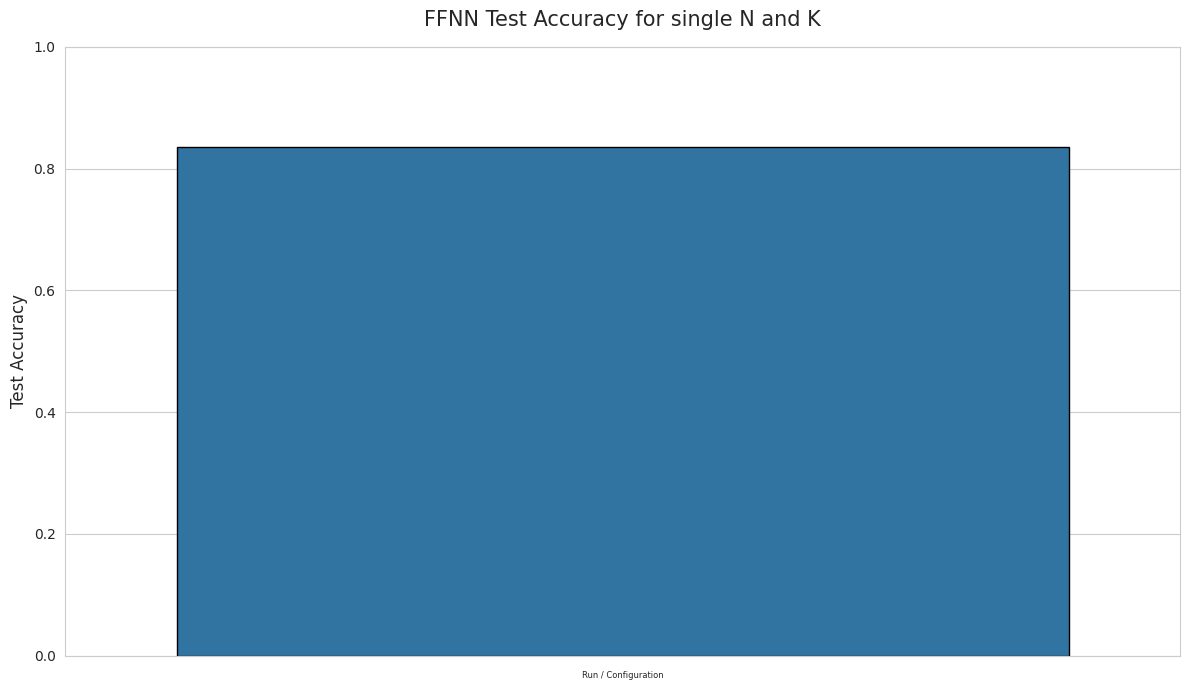

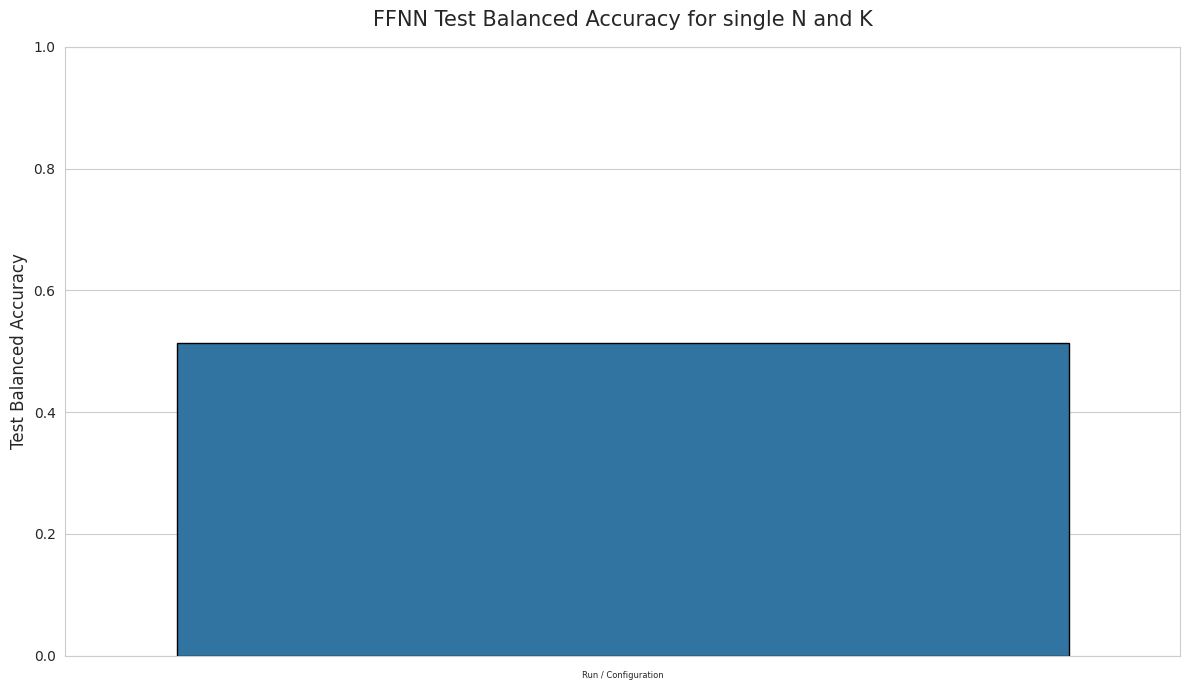

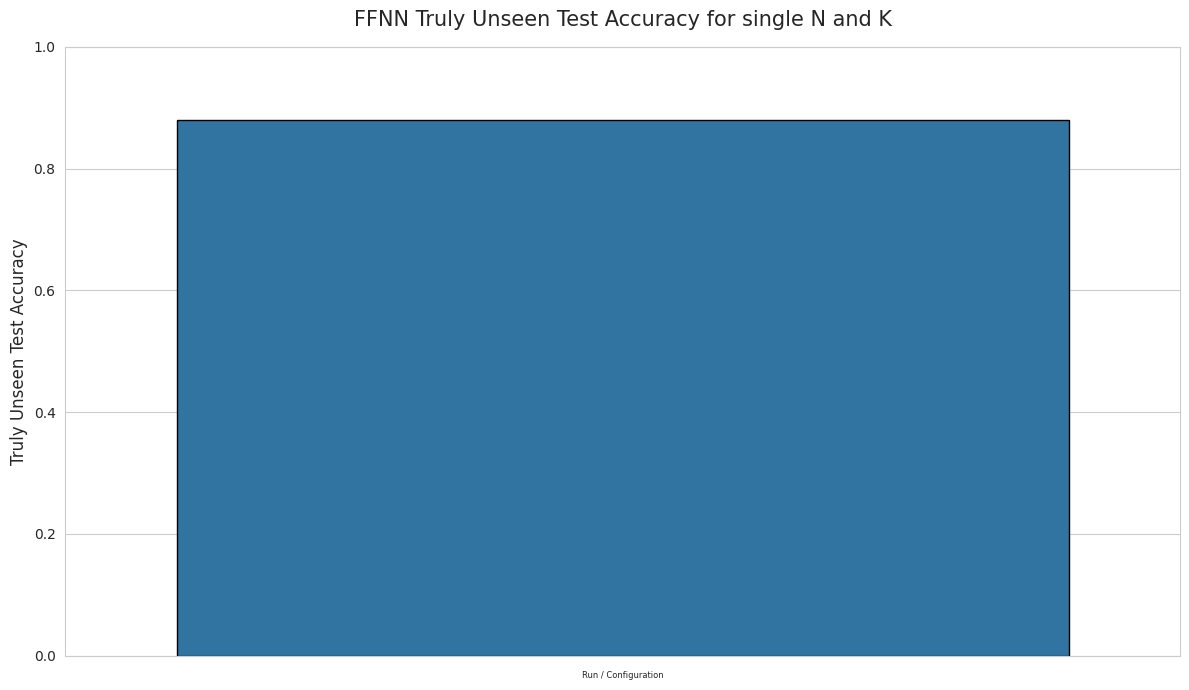

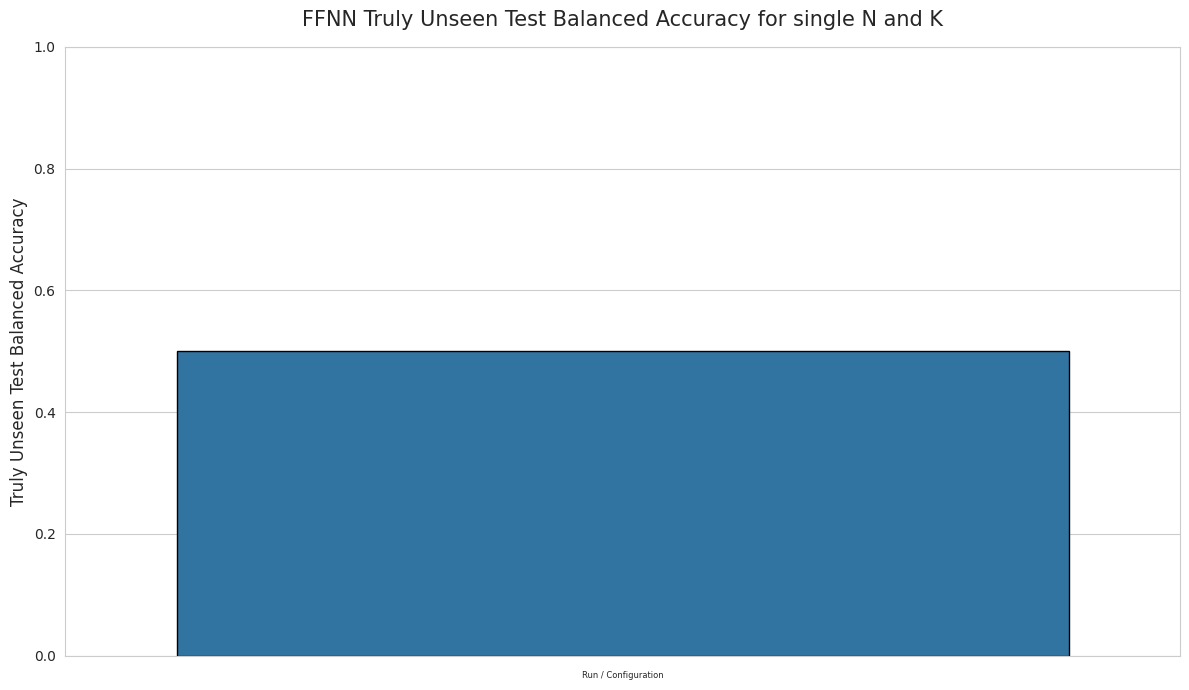

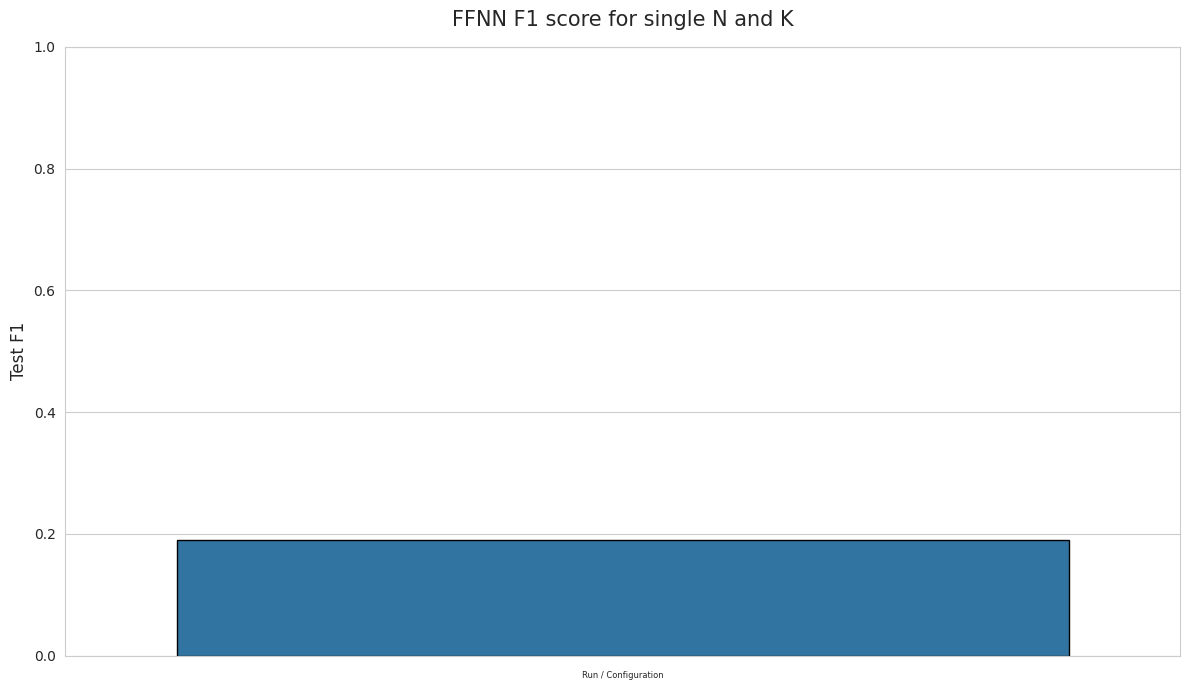

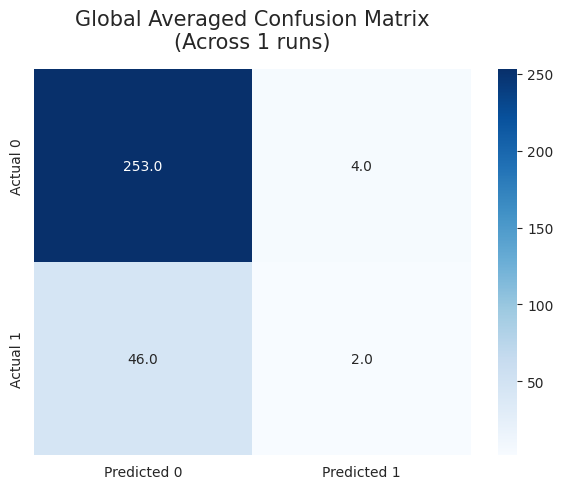

In [2]:
# Update mock_args if you want different settings for this run
cr.args.top_kmers   = 1000
cr.args.weight_pfi  = True
cr.args.filter_harsh = False

cr.main(
    base_dir = nn_dir,
    outdir   = data_prod_path + nn_run_dir_name+ "/",
    x_col    = None,
    hue_col  = None,
    group_x_col  = None,
    group_hue_col = None,
)

---
## Per-partition GAPlottingUtils

The cells below run the full annotation + GAPlottingUtils pipeline on **each partition folder
individually**, rather than pooling everything together as `main()` does.

Each partition gets its own subdirectory under `BASE_OUT` so the plots never overwrite each other.

**Pipeline per folder:**
1. Parse the log file → extract metrics + run_info
2. Calculate UPS from those metrics; attach `UPS` and `test_accuracy` to `df_kmers`
3. Load `pair_kmers.csv`; rename `norm_int_rate_score` → `PFI` if present
4. Optionally compute `WPFI = PFI × test_accuracy` (mirrors `weight_pfi` flag)
5. Resolve `sort_by`: `WPFI` → `PFI` → `UPS` (same priority as `main()`)
6. Split into `bact_df` / `phage_df` using the `bact_*` / `phage_*` column prefixes
   and extract `hash` from the `pair` column — matching the updated split logic in the script
7. Subset to top-k kmers via `balanced_top_k`
8. Annotate with `GeneAnalysis`
9. Instantiate `GAPlottingUtils(sort_by=sort_by)` and run all plot methods

In [3]:
def resolve_sort_by(df_kmers: pd.DataFrame, weight_pfi: bool) -> tuple:
    """
    Determine the score column and title suffix to use for sorting,
    following the same priority logic as main():
      weight_pfi=True  → WPFI (PFI × test_accuracy) if possible, else PFI
      weight_pfi=False → PFI if present, else UPS

    Returns (sort_by: str, title_suffix: str, df_kmers: pd.DataFrame)
    with WPFI column added to df_kmers when applicable.
    """
    # Normalise column name produced by older runs
    if 'norm_int_rate_score' in df_kmers.columns and 'PFI' not in df_kmers.columns:
        df_kmers = df_kmers.rename(columns={'norm_int_rate_score': 'PFI'})

    if 'PFI' in df_kmers.columns:
        if weight_pfi:
            if 'test_accuracy' in df_kmers.columns:
                df_kmers['WPFI'] = df_kmers['PFI'] * df_kmers['test_accuracy']
                return 'WPFI', '(WPFI)', df_kmers
            else:
                print("Warning: 'test_accuracy' missing — cannot weight PFI. Falling back to PFI.")
        return 'PFI', '(PFI)', df_kmers

    return 'UPS', '(UPS)', df_kmers


def split_bact_phage(df_kmers: pd.DataFrame) -> tuple:
    """
    Split a pair_kmers DataFrame into bact_df and phage_df using the
    bact_* / phage_* column prefixes and hash extraction from `pair`,
    exactly as main() does in the updated script.

    Score columns (PFI, UPS, test_accuracy, WPFI) are carried through
    whichever are present.

    Returns (bact_df, phage_df).
    """
    score_cols = [c for c in ('PFI', 'UPS', 'test_accuracy', 'WPFI') if c in df_kmers.columns]
    base_cols  = score_cols + ['folder']

    # ── Bacterium ─────────────────────────────────────────────────────────
    bact_df = df_kmers[['bact_entity', 'bact_organism', 'bact_decoded_kmer'] + base_cols].copy()
    bact_df = bact_df.rename(columns={
        'bact_entity':      'entity',
        'bact_organism':    'organism',
        'bact_decoded_kmer':'decoded_kmer',
    })
    if 'pair' in df_kmers.columns:
        try:
            bact_df.insert(0, 'hash',
                df_kmers['pair'].str.extract(r'np\.int64\((\d+)\)')[0].astype('int64'))
        except Exception as e:
            print(f"Could not extract bact hash from 'pair' column: {e}")

    # ── Phage ─────────────────────────────────────────────────────────────
    phage_df = df_kmers[['phage_entity', 'phage_organism', 'phage_decoded_kmer'] + base_cols].copy()
    phage_df = phage_df.rename(columns={
        'phage_entity':      'entity',
        'phage_organism':    'organism',
        'phage_decoded_kmer':'decoded_kmer',
    })
    if 'pair' in df_kmers.columns:
        try:
            phage_df.insert(0, 'hash',
                df_kmers['pair'].str.extract(r'np\.int64\(\d+\).*?np\.int64\((\d+)\)')[0].astype('int64'))
        except Exception as e:
            print(f"Could not extract phage hash from 'pair' column: {e}")

    return bact_df, phage_df


def plot_partition(folder_path, folder_name, base_out,
                   top_kmers=500, network_top_kmers=50,
                   hk_lookup_path=None, weight_pfi=False):
    """
    Run GAPlottingUtils plots for a single partition folder.

    Parameters
    ----------
    folder_path      : str  – absolute path to the partition directory
    folder_name      : str  – name used for plot titles and the output subdirectory
    base_out         : str  – root output dir; a per-partition subfolder is created inside it
    top_kmers        : int  – passed to balanced_top_k
    network_top_kmers: int  – passed to plot_kmer_gene_network
    hk_lookup_path   : str  – explicit path to a hk_lookup JSON; None → deduced from run_info
    weight_pfi       : bool – mirrors the --weight_pfi CLI flag:
                              True  → sort by WPFI (PFI × test_accuracy)
                              False → sort by PFI if available, else UPS

    Returns
    -------
    dict with keys 'bact', 'phage' (annotated DataFrames), 'metrics', 'ups', 'sort_by'
    or None if the folder could not be processed.
    """
    outdir = os.path.join(base_out, folder_name, "")
    os.makedirs(outdir, exist_ok=True)

    # ── 1. Parse log file ─────────────────────────────────────────────────
    metrics, run_info = None, None
    for fname in os.listdir(folder_path):
        if fname.endswith(".txt") and "log_run" in fname.lower():
            result = cr.extract_metrics_from_log(os.path.join(folder_path, fname))
            if result:
                metrics, run_info = result
                break

    if metrics is None:
        print(f"[{folder_name}] No parseable log file — skipping.")
        return None

    # ── 2. UPS and test_accuracy (attached per-row, same as main()) ───────
    ups           = cr.calculate_unified_score(metrics)
    test_accuracy = metrics.get('test_accuracy', None)

    # ── 3. Load normalized_interactions.csv ─────────────────────────────────
    kmers_path = None
    for fname in os.listdir(folder_path):
        if fname.endswith("normalized_interaction.csv"):
            kmers_path = os.path.join(folder_path, fname)
            break

    if kmers_path is None:
        print(f"[{folder_name}] No normalized_interactions.csv — skipping.")
        return None

    df_kmers = pd.read_csv(kmers_path)
    df_kmers['folder']        = folder_name
    df_kmers['UPS']           = ups
    df_kmers['test_accuracy'] = test_accuracy

    # ── 4. Resolve hk_lookup ─────────────────────────────────────────────
    if hk_lookup_path:
        cr.open_hk_lookup(hk_lookup_path, reverse=True)   # side-effect: cached in cr
    elif run_info:
        try:
            dir_name = "encoded_sketches" if run_info.get('use_encoded') else "SM_sketches"
            if run_info.get('data2'):
                dir_name += "_data2"
            hk_path = os.path.join(
                cr.data_prod_path, dir_name,
                f"hk_lookup_n{metrics['n']}_k{metrics['k']}.json"
            )
            cr.open_hk_lookup(hk_path, reverse=True)
        except Exception as e:
            print(f"[{folder_name}] Could not resolve hk_lookup: {e}")

    # ── 5. Determine score column (WPFI / PFI / UPS) ─────────────────────
    sort_by, title_suffix, df_kmers = resolve_sort_by(df_kmers, weight_pfi=weight_pfi)
    print(f"[{folder_name}] Sorting by '{sort_by}'")

    # ── 6. Split into bact_df / phage_df (updated column-prefix logic) ───
    required_bact_cols  = {'bact_entity', 'bact_organism', 'bact_decoded_kmer'}
    required_phage_cols = {'phage_entity', 'phage_organism', 'phage_decoded_kmer'}

    if not required_bact_cols.issubset(df_kmers.columns) and \
       not required_phage_cols.issubset(df_kmers.columns):
        print(f"[{folder_name}] pair_kmers.csv is missing bact_*/phage_* columns — skipping.")
        return None

    bact_df, phage_df = split_bact_phage(df_kmers)

    # ── 7. Subset to top_kmers per entity ────────────────────────────────
    if not bact_df.empty and sort_by in bact_df.columns:
        bact_df = cr.balanced_top_k(
            bact_df, group_cols=['entity'], sort_col=sort_by, total_k=top_kmers
        )
    if not phage_df.empty and sort_by in phage_df.columns:
        phage_df = cr.balanced_top_k(
            phage_df, group_cols=['entity'], sort_col=sort_by, total_k=top_kmers
        )

    # ── 8. Annotate ───────────────────────────────────────────────────────
    GA = cr.GeneAnalysis()
    bact_annot  = pd.DataFrame()
    phage_annot = pd.DataFrame()

    if not bact_df.empty:
        try:
            # bact_annot = GA.batch_bact_annotate(
            #     bkmers     = bact_df['decoded_kmer'].tolist(),
            #     bact_names = bact_df['entity'].tolist(),
            #     data_prod_path = cr.data_prod_path,
            # )
            bact_annot = GA.batch_bact_annotate(
                bact_df=bact_df, 
                kmer_col='decoded_kmer', 
                entity_col='entity', 
                data_prod_path=data_prod_path
            )
            print(f"[{folder_name}] Bacterium annotation: {len(bact_annot)} rows")
        except Exception as e:
            print(f"[{folder_name}] Bacterium annotation failed: {e}")

    if not phage_df.empty:
        try:
            phage_annot = GA.batch_phage_annotate(
                phage_df=phage_df, 
                kmer_col='decoded_kmer', 
                entity_col='entity', 
                data_prod_path=data_prod_path
            )
            print(f"[{folder_name}] Phage annotation: {len(phage_annot)} rows")
        except Exception as e:
            print(f"[{folder_name}] Phage annotation failed: {e}")

    # ── 9. Plot ───────────────────────────────────────────────────────────
    # GAPlottingUtils now receives sort_by at construction time
    ga_plotter = cr.GAPlottingUtils(df=df_kmers, outdir=outdir, sort_by=sort_by)
    bact_df_agg = bact_annot.groupby("gene")["kmer_in_seq"].agg(lambda x: ';'.join(sorted(set([str(v) for v in x if pd.notna(v)])))).reset_index()
    display(bact_df_agg)
    display(bact_annot)

    if not bact_annot.empty:
        ga_plotter.plot_top_genes(
            bact_annot, entity_type='bacterium', title_suffix=f'{title_suffix} ({folder_name})')
        ga_plotter.plot_kmer_distribution(
            bact_annot, entity_type='bacterium', title_suffix=f'{title_suffix} ({folder_name})')
        ga_plotter.plot_kmer_gene_network(
            bact_annot, entity_type='bacterium', top_kmers=network_top_kmers)
        # plot_kmer_against_ups_or_pfi uses self.sort_by — no argument needed
        ga_plotter.plot_kmer_against_ups_or_pfi(bact_annot, entity_type='bacterium')

    if not phage_annot.empty:
        ga_plotter.plot_top_genes(
            phage_annot, entity_type='phage', title_suffix=f'{title_suffix} ({folder_name})')
        ga_plotter.plot_kmer_distribution(
            phage_annot, entity_type='phage', title_suffix=f'{title_suffix} ({folder_name})')
        ga_plotter.plot_kmer_gene_network(
            phage_annot, entity_type='phage', top_kmers=network_top_kmers)
        ga_plotter.plot_kmer_against_ups_or_pfi(phage_annot, entity_type='phage')

    if bact_annot.empty and phage_annot.empty:
        print(f"[{folder_name}] Both annotation DataFrames empty — no plots generated.")
    else:
        print(f"[{folder_name}] Plots saved to: {outdir}")

    return {
        'bact':    bact_annot,
        'phage':   phage_annot,
        'metrics': metrics,
        'ups':     ups,
        'sort_by': sort_by,
    }

In [4]:
# ── Configure and run the per-partition loop ──────────────────────────────
BASE_DIR = nn_dir
BASE_OUT = data_prod_path + "TEST/" + nn_run_dir_name + "/"

# Optional: restrict to a subset of folders for a quick test
# ONLY_FOLDERS = {'cluster_1_PhageA', 'cluster_2_PhageB'}  # set to None to process all
ONLY_FOLDERS = {"cluster_bX_pX_run3"}

TOP_KMERS         = 50
NETWORK_TOP_KMERS = 500
HK_LOOKUP_PATH    = None   # or a path string to override auto-deduction
WEIGHT_PFI        = False  # set True to sort by WPFI instead of PFI

partition_results = {}

for folder_name in sorted(os.listdir(BASE_DIR)):
    if ONLY_FOLDERS and folder_name not in ONLY_FOLDERS:
        continue
    folder_path = os.path.join(BASE_DIR, folder_name)
    if not os.path.isdir(folder_path):
        continue

    partition_results[folder_name] = plot_partition(
        folder_path       = folder_path,
        folder_name       = folder_name,
        base_out          = BASE_OUT,
        top_kmers         = TOP_KMERS,
        network_top_kmers = NETWORK_TOP_KMERS,
        hk_lookup_path    = HK_LOOKUP_PATH,
        weight_pfi        = WEIGHT_PFI,
    )

succeeded = [k for k, v in partition_results.items() if v is not None]
print(f"\nDone. {len(succeeded)}/{len(partition_results)} partitions processed successfully.")

[cluster_bX_pX_run3] No normalized_interactions.csv — skipping.

Done. 0/1 partitions processed successfully.


In [ ]:
# ── Inspect results for a single partition without re-running ─────────────
# Change the name below to any key from partition_results.
INSPECT = succeeded[0] if succeeded else None

if INSPECT:
    r = partition_results[INSPECT]
    print(f"=== {INSPECT} ===")
    print(f"UPS:     {r['ups']}")
    print(f"sort_by: {r['sort_by']}")
    print(f"Metrics: {r['metrics']}\n")

    if not r['bact'].empty:
        print("Bacterium annotation (head):")
        display(r['bact'].head())

    if not r['phage'].empty:
        print("Phage annotation (head):")
        display(r['phage'].head())
else:
    print("No successful partitions to inspect.")

In [ ]:
# ── Quick score summary across all partitions ─────────────────────────────
summary = pd.DataFrame([
    {
        'partition': k,
        'sort_by':   v['sort_by'],
        'ups':       v['ups'],
        **{m: v['metrics'].get(m) for m in
           ['test_balanced_accuracy', 'unseen_test_balanced_accuracy', 'f1']}
    }
    for k, v in partition_results.items() if v is not None
]).sort_values('ups', ascending=False)

display(summary)